## Probabilistic PCA with ARD for AML / ALL / Normal Classification


## Table of Contents

1. [Introduction](#introduction)  
2. [Environment Setup & Packages](#environment-setup-packages)  
3. [Data Loading & Preprocessing](#data-loading-preprocessing)  
4. [Model Definition: PPCA with ARD](#model-definition-ppca-with-ard)  
5. [Inference Setup](#inference-setup)  
6. [Model Training](#model-training)  
7. [Evaluation & Classification](#evaluation-classification)  
8. [Results & Visualization](#results-visualization)  
9. [Conclusion & Future Work](#conclusion-future-work)  


<!-- Anchor for Introduction -->
<a id="introduction"></a>
## 1. Introduction

_An end-to-end implementation of Probabilistic PCA using Automatic Relevance Determination priors, trained via Stochastic Variational Inference on gene expression data to distinguish between Acute Myeloid Leukemia (AML), Acute Lymphoblastic Leukemia (ALL), and normal samples._


<!-- Anchor for Environment Setup -->
<a id="environment-setup-packages"></a>
## 2. Environment Setup & Packages

Before diving into the model implementation, we load all of the libraries and modules we’ll need throughout this notebook.


In [ ]:
# ─────────────── Timing Utilities ───────────────
import time                   # time.sleep, performance measurement

# ─────────────── Data Handling ────────────────
import pandas as pd           # pd.read_csv, DataFrame operations
import numpy as np            # np.random.seed, array operations

# ─────────────── Deep Learning & Probabilistic Programming ───────────────
import torch                  # torch.Tensor, torch.nn.Module, torch.optim
import pyro                   # pyro.set_rng_seed, framework entry point
import pyro.distributions as dist      # probability distributions (Normal, Gamma, etc.)
from pyro.infer import SVI, Trace_ELBO # variational inference API
from pyro.optim import ClippedAdam, Adam  # optimizers with (optional) gradient clipping

# ─────────────── Visualization ───────────────
import matplotlib.pyplot as plt  # plt.subplots, plt.plot, plt.show
import seaborn as sns            # sns.set_style, sns.scatterplot, statistical plots

# ─────────────── Evaluation & Manifold Learning ───────────────
from sklearn.metrics import confusion_matrix  # compute classification confusion matrix
from sklearn.manifold import TSNE            # t-SNE for latent-space visualization


# ─────────────── Related modules ───────────────
from featureimportance import compute_feature_importance_from_AW,plot_top_genes_from_AW,plot_all_genes_from_AW



<!-- Anchor for Environment Setup -->
<a id="data-loading-preprocessing"></a>
## 3. Loading of Training and Validation Data

Before diving into the model implementation, we load all of the libraries and modules we’ll need throughout this notebook.


In [ ]:
def load_small_data():
    pyro.set_rng_seed(42)

    # Load small dataset
    test_data_path = "small_test_data.csv"
    test_label_path = "small_test_labels.csv"
    test_data = pd.read_csv(test_data_path).values.astype(np.float32)
    test_label = pd.read_csv(test_label_path).values.flatten()

    val_data_path = "small_val_data.csv"
    val_label_path = "small_val_labels.csv"
    val_data = pd.read_csv(val_data_path).values.astype(np.float32)
    val_label = pd.read_csv(val_label_path).values.flatten()

    genes_path = "gene_label.csv"
    gene_names = pd.read_csv(genes_path, header=None).values[:400,0]
    gene_type = pd.read_csv(genes_path, header=None).values[:400,1]

    return test_data, test_label, val_data, val_label, gene_names, gene_type



def load_large_data():
    pyro.set_rng_seed(42)
    torch.set_num_threads(8)

    # File paths
    train_path = "/work3/s214806/working_chunk_train.csv"
    val_path = "/work3/s214806/working_chunk_val.csv"
    test_path = "/work3/s214806/working_chunk_test.csv"

    LABEL_MAPPING = {'AML': 0, 'ALL': 1, 'Normal': 2}



    # Load and preprocess data
    def load_and_preprocess(path):
        df = pd.read_csv(path, index_col=0, low_memory=False).T
        print(f"Gene expression data BEFORE removing non-numeric columns: {df.shape[1]}")

        labels = df['Cancer'].map(LABEL_MAPPING).dropna()

        gene_expressions = df.drop(['Cancer', 'Preservation Method', 'Tissue Type', 'Tumor Descriptor', 'Specimen Type'], 
                                axis=1, errors='ignore')

        gene_expressions = gene_expressions.apply(pd.to_numeric, errors='coerce')
        gene_expressions = gene_expressions.dropna(axis=1)
        print(f"Gene expression data AFTER removing non-numeric columns: {gene_expressions.shape[1]}")

        gene_expressions = gene_expressions.astype(np.float32)
        return gene_expressions.values, labels.loc[gene_expressions.index].values
    



    # Load your data using your function
    X_train, y_train = load_and_preprocess(train_path)
    X_val, y_val = load_and_preprocess(val_path)
    X_test, y_test = load_and_preprocess(test_path)

    print("X_train shape:", X_train.shape)
    print("y_train shape:", y_train.shape)

    print("X_val shape:", X_val.shape)
    print("y_val shape:", y_val.shape)

    print("X_test shape:", X_test.shape)
    print("y_test shape:", y_test.shape)

    genes_path = "gene_label.csv"
    gene_names = pd.read_csv(genes_path, header=None).values[:,0]
    gene_type = pd.read_csv(genes_path, header=None).values[:,1]

    return X_train, y_train, X_val, y_val, X_test, y_test, gene_names, gene_type




Toggle = "large"


if Toggle == "small":
    X_train, y_train, X_val, y_val, gene_names, _ = load_small_data()
elif Toggle == "large":
    X_train, y_train, X_val, y_val, X_test, y_test, gene_names, _ = load_large_data()


Test data shape: (200, 400)
Test label shape: (200, 1)
Example features from first test sample: [5.53000e-02 0.00000e+00 5.55492e+01 4.71580e+00 3.67360e+00 2.70879e+01
 1.88500e-01 1.50104e+01 1.45420e+01 1.54886e+01]


In [ ]:
def normalize_data(data):
    # Z-score normalization per gene
    X_train_mean = data.mean(axis=0)
    X_train_std = data.std(axis=0) + 1e-6  # avoid div-by-zero
    X_norm = (data - X_train_mean) / X_train_std
    X_clipped = np.clip(X_norm, -10, 10)
    return X_clipped, X_train_mean, X_train_std

X_log = np.log1p(X_train)
X_norm, X_train_mean, X_train_std = normalize_data(X_log)

<!-- Anchor for Environment Setup -->
<a id="model-definition-ppca-with-ard"></a>
## 3. Model definition of PPCA with ARD



In [ ]:
def supervised_ppca_model_ard(X, y, latent_dim, n_classes):
    n_samples, n_genes = X.shape


    a0, b0 = torch.tensor(1e-1), torch.tensor(1e-1)
    alpha = pyro.sample("alpha", dist.Gamma(a0.expand(latent_dim), b0.expand(latent_dim)).to_event(1))

    # (2) Loading matrix W with ARD prior (each latent factor scaled by α)
    # W_qd ~ N(0, 1/α_q) ⇒ W ~ N(0, diag(1/α)) component-wise
    W = pyro.sample("W", dist.Normal(torch.zeros(latent_dim, n_genes), alpha.unsqueeze(-1).rsqrt()).to_event(2))

    # (3) Bayesian logistic regression parameters for classification head
    # A_kq ~ N(0,1), b_k ~ N(0,1) for class weights and bias
    A = pyro.sample("A", dist.Normal(0., 1.).expand([n_classes, latent_dim]).to_event(2))
    b = pyro.sample("b", dist.Normal(0., 1.).expand([n_classes]).to_event(1))

    # (4) Per-gene observation noise σ (model parameter)
    # σ_d is fixed and positive; used in X ~ N(z @ W, σ)
    sigma = pyro.param("sigma_loc", torch.full((n_genes,), 0.1), constraint=dist.constraints.positive)

    # (5) Generative process for each data sample
    with pyro.plate("data", n_samples):
        # Latent representation z per sample
        # z_n ~ N(0, diag(1/α)) for each sample n
        z = pyro.sample("z", dist.Normal(0., 1.).expand([latent_dim]).to_event(1))
    
        # Reconstruction of gene expression (observed data X)
        # x_n ~ N(W^T z_n, σ) where σ is a fixed noise vector
        x_loc = torch.matmul(z, W)
        pyro.sample("obs", dist.Normal(x_loc, sigma).to_event(1), obs=X)

        # Classification logits (linear model from latent variables)
        # logits_n = A z_n + b ⇒ y_n ~ Categorical(softmax(logits_n))
        logits = torch.matmul(z, A.T) + b
        pyro.sample("y", dist.Categorical(logits=logits), obs=y)


def supervised_ppca_guide_ard(X, y, latent_dim, n_classes):
    n_samples, n_genes = X.shape


    alpha_a = pyro.param("alpha_a", torch.ones(latent_dim), constraint=dist.constraints.positive)
    alpha_b = pyro.param("alpha_b", torch.ones(latent_dim), constraint=dist.constraints.positive)
    alpha = pyro.sample("alpha", dist.Gamma(alpha_a, alpha_b).to_event(1))

    # (2) Variational posterior over loading matrix W
    # q(W_qd) = N(w_loc_qd, (w_scale_qd / sqrt(α_q))^2)
    w_loc = pyro.param("w_loc", torch.randn(latent_dim, n_genes))
    w_scale = pyro.param("w_scale", torch.ones(latent_dim, n_genes), constraint=dist.constraints.positive)
    pyro.sample("W", dist.Normal(w_loc, w_scale / alpha.unsqueeze(-1).sqrt()).to_event(2))

    # (3) Variational posterior over classification parameters A and bias b
    # q(A_kq) = N(A_loc_kq, A_scale_kq^2), q(b_k) = N(b_loc_k, b_scale_k^2)
    A_loc = pyro.param("A_loc", torch.randn(n_classes, latent_dim))
    A_scale = pyro.param("A_scale", torch.ones(n_classes, latent_dim), constraint=dist.constraints.positive)
    pyro.sample("A", dist.Normal(A_loc, A_scale).to_event(2))

    b_loc = pyro.param("b_loc", torch.zeros(n_classes))
    b_scale = pyro.param("b_scale", torch.ones(n_classes), constraint=dist.constraints.positive)
    pyro.sample("b", dist.Normal(b_loc, b_scale).to_event(1))

    # (4) Variational posterior for latent variables z
    # q(z_nq) = N(z_loc_nq, (z_scale_nq / sqrt(α_q))^2)
    z_loc = pyro.param("z_loc", torch.randn(n_samples, latent_dim))
    z_scale = pyro.param("z_scale", torch.ones(n_samples, latent_dim), constraint=dist.constraints.positive)

    with pyro.plate("data", n_samples):
        pyro.sample("z", dist.Normal(z_loc, z_scale).to_event(1))


In [ ]:
latent_dim = 100
n_classes = 3

X_train_tensor = torch.tensor(X_norm, dtype=torch.float32)
y_train_tensor = torch.tensor(y_train, dtype=torch.long)

In [ ]:
pyro.clear_param_store()

optimizer = ClippedAdam({"lr": 0.05})
svi = SVI(supervised_ppca_model_ard, supervised_ppca_guide_ard, optimizer, loss=Trace_ELBO())

start_time = time.time()

n_steps = 300
for step in range(n_steps):
    loss = svi.step(X_train_tensor, y_train_tensor, latent_dim, n_classes)
    if step % 20 == 0:
        print(f"[Step {step}] Loss: {loss:.2f}")

# Total time spent
print(f"Total time spent: {time.time() - start_time:.2f} seconds ({((time.time() - start_time) / 60):.2f} minutes)")

[Step 0] Loss: 2822375163.55
[Step 200] Loss: 111052.46
[Step 400] Loss: 94230.69
[Step 600] Loss: 93329.25
[Step 800] Loss: 88174.30
[Step 1000] Loss: 86710.16
[Step 1200] Loss: 86270.32
[Step 1400] Loss: 84340.28
[Step 1600] Loss: 87852.51
[Step 1800] Loss: 84592.45
[Step 2000] Loss: 86571.42
[Step 2200] Loss: 86121.87
[Step 2400] Loss: 84272.90
[Step 2600] Loss: 85092.14
[Step 2800] Loss: 88611.02
[Step 3000] Loss: 84164.88
[Step 3200] Loss: 84301.14
[Step 3400] Loss: 83838.75
Total time spent: 37.47 seconds
Total time spent: 0.62 minutes


In [8]:
print(list(pyro.get_param_store().keys()))

['alpha_a', 'alpha_b', 'w_loc', 'w_scale', 'A_loc', 'A_scale', 'b_loc', 'b_scale', 'z_loc', 'z_scale', 'sigma_loc']


In [ ]:
#1) Pull in and compute your ARD precision means
alpha_a = pyro.param("alpha_a").detach().cpu().numpy()
alpha_b = pyro.param("alpha_b").detach().cpu().numpy()
alpha_mean = alpha_a / alpha_b
latent_dim = alpha_mean.shape[0]

# 2) Effective W std (average over genes)
w_scale    = pyro.param("w_scale").detach().cpu().numpy()
w_eff_mean = (w_scale / np.sqrt(alpha_mean[:, None])).mean(axis=1)

# 3) Effective z std (average over samples)
z_scale    = pyro.param("z_scale").detach().cpu().numpy()
z_eff_mean = (z_scale / np.sqrt(alpha_mean)).mean(axis=0)

# 4) Now plot—all variables are defined
x     = np.arange(latent_dim)
width = 0.8  # data‐unit width

fig, axes = plt.subplots(1, 3, figsize=(15, 4), sharex=True)

axes[0].bar(x, alpha_mean,   width=width, align="center")
axes[0].set(title="ARD Precision per Latent Dimension", ylabel="Value")

axes[1].bar(x, w_eff_mean,   width=width, align="center")
axes[1].set(title="Effective Weight Std")

axes[2].bar(x, z_eff_mean,   width=width, align="center")
axes[2].set(title="Effective Latent Std")

for ax in axes:
    ax.set_xlabel("Latent Dimension")
    ax.set_xlim(-0.5, latent_dim - 0.5)

plt.tight_layout()
plt.show()

# plot of alpha_mean
plt.figure(figsize=(8, 4))
plt.plot(alpha_mean, marker='o', linestyle='-', color='b')
plt.title("ARD Precision per Latent Dimension")
plt.xlabel("Latent Dimension")
plt.ylabel("Precision (α)")
plt.grid()
plt.tight_layout()
plt.show()

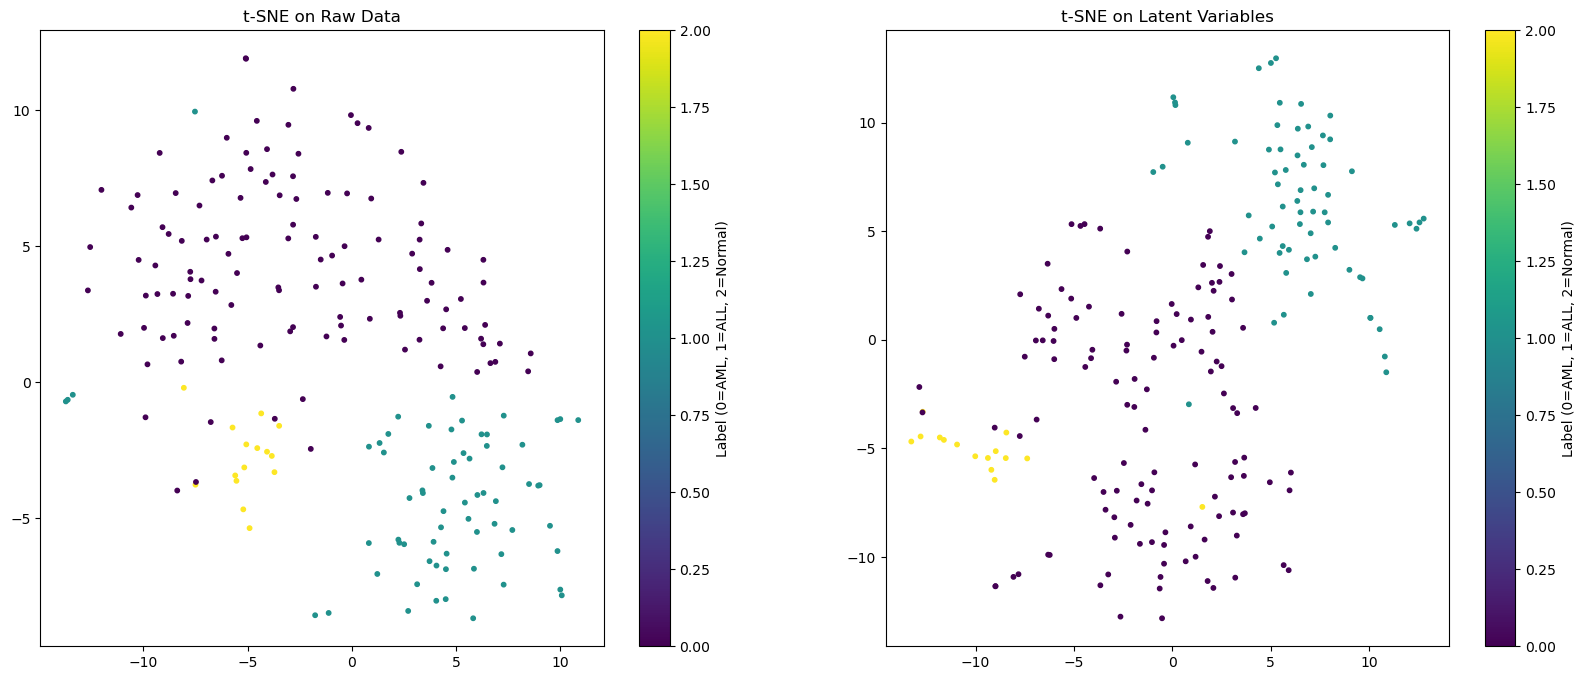

In [ ]:
def TSNE_plots(z_loc, labels):
    raw_data_tsne = TSNE(n_components=2).fit_transform(X_train)
    z_post_tsne = TSNE(n_components=2).fit_transform(z_loc.detach().cpu().numpy())

    plt.figure(figsize=(20, 8))
    plt.subplot(1, 2, 1)
    plt.scatter(raw_data_tsne[:, 0], raw_data_tsne[:, 1], c=labels.flatten(), cmap='viridis', s=10)
    plt.title("t-SNE on Raw Data")
    plt.colorbar(label='Label (0=AML, 1=ALL, 2=Normal)')
    plt.subplot(1, 2, 2)
    plt.scatter(z_post_tsne[:, 0], z_post_tsne[:, 1], c=labels.flatten(), cmap='viridis', s=10)
    plt.title("t-SNE on Latent Variables")
    plt.colorbar(label='Label (0=AML, 1=ALL, 2=Normal)')
    plt.show()

z_loc = pyro.param("z_loc").detach()
TSNE_plots(z_loc, y_train)


In [ ]:
X_val_norm = normalize_data(np.log1p(X_val))[0]
X_val_tensor = torch.tensor(X_val_norm, dtype=torch.float32)

In [ ]:
# --- assume your training SVI has run and ps is populated ---
ps       = pyro.get_param_store()
W_pm     = ps["w_loc"].detach()                    # [latent_dim, n_genes]
sigma_pm = ps["sigma_loc"].detach()                # scalar or [n_genes]
A_pm     = ps["A_loc"].detach()                    # [n_classes, latent_dim]
b_pm     = ps["b_loc"].detach()                    # [n_classes]

# TEST

In [ ]:
# --- 1) Unsupervised PPCA “model” that only generates X under locked params ---
def infer_z_model(X):
    N = X.shape[0]

    with pyro.plate("data", N):
        # ARD‐scaled prior on z
        z = pyro.sample("z", dist.Normal(0., 1.).expand([latent_dim]).to_event(1))
        # likelihood for X under fixed W, sigma
        x_loc = torch.matmul(z, W_pm)                     # [N_val, n_genes]
        pyro.sample("x", dist.Normal(x_loc, sigma_pm).to_event(1), obs=X)

# --- 2) Guide that only learns z_loc_val / z_scale_val ---
def infer_z_guide(X):
    N = X.shape[0]

    z_loc   = pyro.param("z_loc_test", torch.randn(N, latent_dim))
    z_scale = pyro.param("z_scale_test", torch.ones(N, latent_dim), constraint=dist.constraints.positive)
    with pyro.plate("data", N):
        pyro.sample("z", dist.Normal(z_loc, z_scale).to_event(1))

# --- 3) Run SVI on X only to infer z_loc_val / z_scale_val ---
# (do NOT clear the ParamStore here if you want to keep W_pm etc.)
optimizer_inf = ClippedAdam({"lr": 0.05})
svi_inf       = SVI(infer_z_model, infer_z_guide, optimizer_inf, loss=Trace_ELBO())

start = time.time()
n_steps = 300
for step in range(n_steps):
    loss = svi_inf.step(X_val_tensor)
    if step % 20 == 0:
        print(f"[val step {step}] loss = {loss:.1f}")


print(f"Total time spent: {time.time() - start_time:.2f} seconds ({((time.time() - start_time) / 60):.2f} minutes)")


In [ ]:
# --- 4) Extract your inferred latent means ---
z_loc_test = pyro.param("z_loc_test").detach()   # [n_val_samples, latent_dim]

# --- 5) Prediction function ---
def predict_classes(z_loc, A, b, y_true):
    # Compute logits and probabilities
    logits = torch.matmul(z_loc, A.T) + b
    probs  = torch.softmax(logits, dim=-1)
    y_hat  = torch.argmax(probs, dim=-1).cpu().numpy()

    # Compute accuracy
    y_true = np.array(y_true)
    accuracy = (y_true == y_hat).mean()
    print(f"Validation Accuracy: {accuracy:.4f}")

    # Confusion matrix
    conf_matrix = confusion_matrix(y_true, y_hat)
    plt.figure(figsize=(8, 6))
    sns.heatmap(
        conf_matrix,
        annot=True,
        fmt="d",
        cmap="Blues",
        xticklabels=["AML", "ALL", "Normal"],
        yticklabels=["AML", "ALL", "Normal"]
    )
    plt.xlabel("Predicted Labels")
    plt.ylabel("True Labels")
    plt.title("Confusion Matrix")
    plt.show()

    return y_hat

# --- 6) Call prediction with correct params ---
y_hat_val = predict_classes(z_loc_test, A_pm, b_pm, y_val)


In [ ]:
# Example usage
W = pyro.param("w_loc").detach().cpu().numpy()  # Shape: [latent_dim, n_genes]
A = A_pm.detach().cpu().numpy()                # Shape: [n_classes, latent_dim]
top_n = 20
gene_importance = np.linalg.norm(A @ W, axis=0)  # Compute importance for all genes


# Compute feature importance
top_indices, top_importance = compute_feature_importance_from_AW(W, A, top_n=top_n)

# Plot the top genes
plot_top_genes_from_AW(top_indices, top_importance, top_n=top_n, gene_names=gene_names)
plot_all_genes_from_AW(gene_importance)

# VALIDATION

In [ ]:
# --- 1) Unsupervised PPCA “model” that only generates X under locked params ---
def infer_z_val_model(X):
    N = X.shape[0]

    with pyro.plate("data", N):
        # ARD‐scaled prior on z
        z = pyro.sample("z", dist.Normal(0., 1.).expand([latent_dim]).to_event(1))
        # likelihood for X under fixed W, sigma
        x_loc = torch.matmul(z, W_pm)                     # [N_val, n_genes]
        pyro.sample("x", dist.Normal(x_loc, sigma_pm).to_event(1), obs=X)

# --- 2) Guide that only learns z_loc_val / z_scale_val ---
def infer_z_val_guide(X):
    N = X.shape[0]

    z_loc   = pyro.param("z_loc_val", torch.randn(N, latent_dim))
    z_scale = pyro.param("z_scale_val", torch.ones(N, latent_dim), constraint=dist.constraints.positive)
    with pyro.plate("data", N):
        pyro.sample("z", dist.Normal(z_loc, z_scale).to_event(1))

# --- 3) Run SVI on X only to infer z_loc_val / z_scale_val ---
# (do NOT clear the ParamStore here if you want to keep W_pm etc.)
optimizer_inf = ClippedAdam({"lr": 0.05})
svi_inf       = SVI(infer_z_val_model, infer_z_val_guide, optimizer_inf, loss=Trace_ELBO())

start = time.time()
n_steps = 300
for step in range(n_steps):
    loss = svi_inf.step(X_val_tensor)
    if step % 20 == 0:
        print(f"[val step {step}] loss = {loss:.1f}")


print(f"Total time spent: {time.time() - start_time:.2f} seconds ({((time.time() - start_time) / 60):.2f} minutes)")


[val step 0] loss = 1572680.1
[val step 300] loss = 126372.0
[val step 600] loss = 93899.7
[val step 900] loss = 93034.8
[val step 1200] loss = 92968.4
[val step 1500] loss = 92956.3
[val step 1800] loss = 92936.9
[val step 2100] loss = 92973.2
[val step 2400] loss = 92941.8
[val step 2700] loss = 92960.3
[val step 3000] loss = 92954.5
[val step 3300] loss = 92951.2
[val step 3600] loss = 92961.5
[val step 3900] loss = 92949.4
[val step 4200] loss = 92939.0
[val step 4500] loss = 92974.1
[val step 4800] loss = 92947.1
Inference took 18.6s


Validation Accuracy: 0.9350


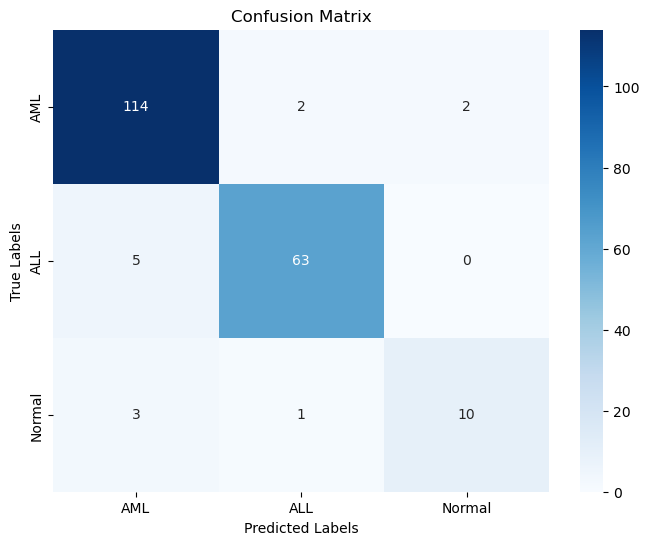

In [ ]:
# --- 4) Extract your inferred latent means ---
z_loc_val = pyro.param("z_loc_val").detach()   # [n_val_samples, latent_dim]

# --- 5) Prediction function ---
def predict_classes(z_loc, A, b, y_true):
    # Compute logits and probabilities
    logits = torch.matmul(z_loc, A.T) + b
    probs  = torch.softmax(logits, dim=-1)
    y_hat  = torch.argmax(probs, dim=-1).cpu().numpy()

    # Compute accuracy
    y_true = np.array(y_true)
    accuracy = (y_true == y_hat).mean()
    print(f"Validation Accuracy: {accuracy:.4f}")

    # Confusion matrix
    conf_matrix = confusion_matrix(y_true, y_hat)
    plt.figure(figsize=(8, 6))
    sns.heatmap(
        conf_matrix,
        annot=True,
        fmt="d",
        cmap="Blues",
        xticklabels=["AML", "ALL", "Normal"],
        yticklabels=["AML", "ALL", "Normal"]
    )
    plt.xlabel("Predicted Labels")
    plt.ylabel("True Labels")
    plt.title("Confusion Matrix")
    plt.show()

    return y_hat

# --- 6) Call prediction with correct params ---
y_hat_val = predict_classes(z_loc_val, A_pm, b_pm, y_val)


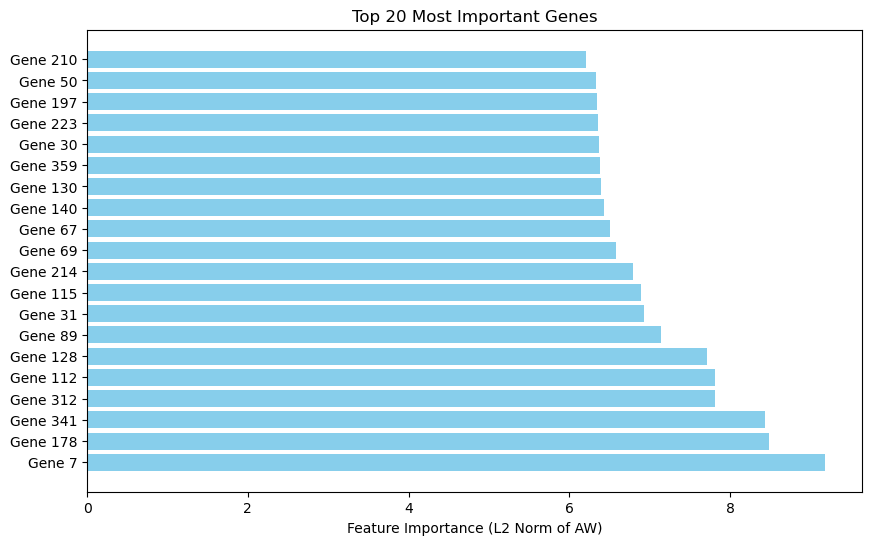

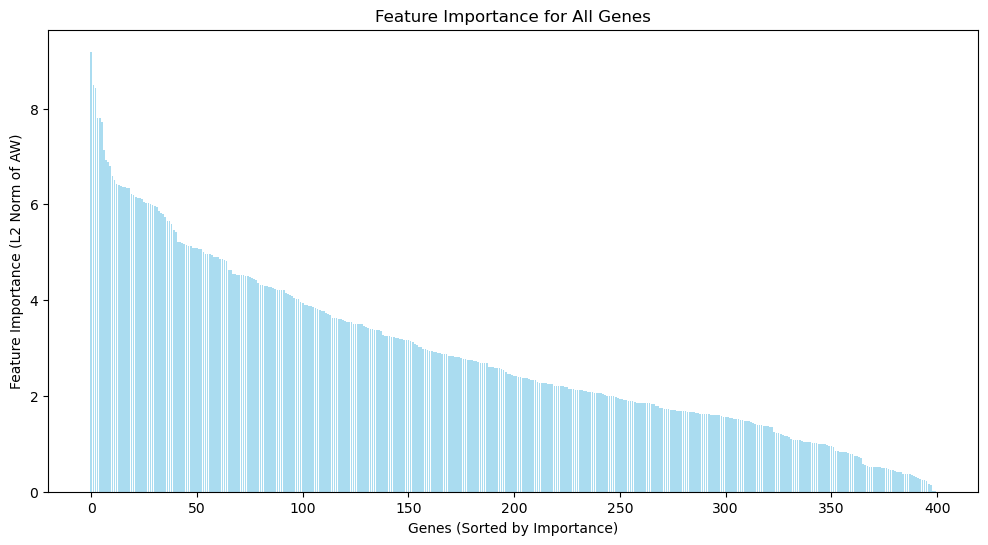

In [ ]:
# Example usage
W = pyro.param("w_loc").detach().cpu().numpy()  # Shape: [latent_dim, n_genes]
A = A_pm.detach().cpu().numpy()                # Shape: [n_classes, latent_dim]
top_n = 20
gene_importance = np.linalg.norm(A @ W, axis=0)  # Compute importance for all genes


# Compute feature importance
top_indices, top_importance = compute_feature_importance_from_AW(W, A, top_n=top_n)

# Plot the top genes
plot_top_genes_from_AW(top_indices, top_importance, top_n=top_n, gene_names=gene_names)
plot_all_genes_from_AW(gene_importance)